# SVG 图层绘图参数交互订正

本 notebook 用于**交互式微调** `src/draw/generate_svg_layers.py` 中各绘图函数的参数，
所有图层在 notebook 中**内联预览**（带海岸线/经纬网底图便于定位），调好参数后再把数值回填到
`generate_svg_layers.py` 即可。

- 默认起报时间 `INIT_TIME = 2026062900`，预报时效 `FC_HOUR = 000`。
- 复用模块里的色标、归一化、数据读取等逻辑，避免重复维护。
- 每个图层一个独立单元格，顶部集中暴露可调参数，改完直接重跑该单元格即可看效果。

> 数据来源默认走 THREDDS（内网地址）。若使用本地 NetCDF，请在「全局配置」单元格里
> 把对应的 `*_PATH` 改为本地文件路径。

## 使用步骤
1. 运行「环境与导入」「全局配置」「数据读取助手」「内联预览助手」四个准备单元格。
2. 跑任意图层单元格，调整顶部参数，重复直到满意。
3. 把满意的参数值回填到 `generate_svg_layers.py` 中对应的 `draw_*` 函数。

## 1. 环境与导入

把 `src/` 和 `src/draw/` 加入路径，并以 `gsl` 别名导入绘图模块，复用其中的色标、归一化与数据读取逻辑。

In [6]:
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# 定位仓库目录结构：notebook 在 src/notebook/ 下
NOTEBOOK_DIR = Path.cwd()
SRC_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebook" else NOTEBOOK_DIR
DRAW_DIR = SRC_ROOT / "draw"
for p in (str(SRC_ROOT), str(DRAW_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

import generate_svg_layers as gsl

# gsl 导入时会执行 matplotlib.use("Agg")（非交互，用于出 SVG），
# 这里必须在导入之后切回 inline 后端，否则 plt.show() 无法在 notebook 内显示。
%matplotlib inline

print("SRC_ROOT =", SRC_ROOT)
print("已导入 generate_svg_layers:", gsl.__file__)
print("当前 matplotlib 后端:", matplotlib.get_backend())

SRC_ROOT = h:\github\weather-system-identification\src
已导入 generate_svg_layers: h:\github\weather-system-identification\src\draw\generate_svg_layers.py
当前 matplotlib 后端: inline


## 2. 全局配置

集中设置起报时间、预报时效、层次、绘图范围、数据来源与 DPI。
- 若使用**本地 NetCDF**，把对应 `*_PATH` 改为本地文件路径即可（默认 `None` 走 THREDDS）。
- `LEVEL` 为高空图层默认层次；`BOUNDS = (lon_min, lon_max, lat_min, lat_max)`。

In [ ]:
# ===== 核心配置 =====
INIT_TIME = "2026062900"   # 起报时间 YYYYMMDDHH
FC_HOUR = "000"            # 预报时效（3 位字符串）
LEVEL = 500                # 高空图层默认层次 (hPa)
BOUNDS = (60.0, 180.0, 0.0, 60.0)  # lon_min, lon_max, lat_min, lat_max
DPI = 150                  # 预览/出图 DPI

# ===== 数据来源 =====
SOURCE = gsl.DEFAULT_SOURCE
BASE_URL_TEMPLATE = gsl.DEFAULT_BASE_URL_TEMPLATE

# ===== 数据文件路径（None=走 THREDDS；填字符串=用本地/远程文件）=====
UWND_PATH = None   # 高空 U 风  uwnd.nc
VWND_PATH = None   # 高空 V 风  vwnd.nc
HGHT_PATH = None   # 位势高度  hght.nc
TEMP_PATH = None   # 高空温度  temp.nc
VORT_PATH = None   # 相对涡度  vort.nc
RHUM_PATH = None   # 相对湿度  rhum.nc
MSLP_PATH = None   # 海平面气压 mslp.nc
U10_PATH = None    # 10m U 风  u10.nc
V10_PATH = None    # 10m V 风  v10.nc

# ===== 预览底图（海岸线/经纬网，仅预览用，正式出图为透明无底图）=====
SHOW_BASEMAP = True

bounds_obj = gsl.Bounds(*BOUNDS)
print(f"INIT_TIME={INIT_TIME}, FC_HOUR={FC_HOUR}, LEVEL={LEVEL}, BOUNDS={BOUNDS}")

## 3. 数据读取助手

`load_field` 按要素文件名 + 变量候选名读取一个裁剪到 `BOUNDS` 的 `xr.DataArray`，
并带 `@lru_cache` 缓存，避免反复调参时重复请求 THREDDS。各要素提供了便捷封装函数。

In [ ]:
from functools import lru_cache


def _resolve_path(explicit, filename):
    return gsl.default_path(explicit, INIT_TIME, SOURCE, filename, BASE_URL_TEMPLATE)


@lru_cache(maxsize=None)
def _load_cached(path, candidates, level):
    return gsl.open_data_array(path, list(candidates), INIT_TIME, level, bounds_obj)


def load_field(explicit_path, filename, candidate_templates, level):
    """读取单要素 DataArray（裁剪到 BOUNDS、选定时次与层次），结果缓存。"""
    path = _resolve_path(explicit_path, filename)
    candidates = tuple(t.format(fc_hour=FC_HOUR) for t in candidate_templates)
    return _load_cached(path, candidates, level)


# ----- 各要素便捷封装 -----
def load_uwnd(level=LEVEL):
    return load_field(UWND_PATH, "uwnd.nc", ["uwnd{fc_hour}", "uwnd", "u"], level)

def load_vwnd(level=LEVEL):
    return load_field(VWND_PATH, "vwnd.nc", ["vwnd{fc_hour}", "vwnd", "v"], level)

def load_hght(level=LEVEL):
    return load_field(HGHT_PATH, "hght.nc", ["hght{fc_hour}", "hght", "z"], level)

def load_temp(level=LEVEL):
    return load_field(TEMP_PATH, "temp.nc", ["temp{fc_hour}", "temp", "t"], level)

def load_vort(level=LEVEL):
    return load_field(VORT_PATH, "vort.nc", ["vort{fc_hour}", "vort", "vo"], level)

def load_rhum(level=LEVEL):
    return load_field(RHUM_PATH, "rhum.nc", ["rhum{fc_hour}", "rhum", "r"], level)

def load_mslp():
    return load_field(MSLP_PATH, "mslp.nc", ["mslp{fc_hour}", "mslp", "msl"], None)

def load_u10():
    return load_field(U10_PATH, "u10.nc", ["u10{fc_hour}", "u10", "u"], None)

def load_v10():
    return load_field(V10_PATH, "v10.nc", ["v10{fc_hour}", "v10", "v"], None)


print("数据读取助手已就绪。改完路径/层次后如需清缓存：_load_cached.cache_clear()")

## 4. 内联预览助手

`preview_axis` 与模块里的 `setup_axis` 等价，但**保留底图**（海岸线 + 经纬网）方便定位，
并返回 `(fig, ax)` 供各图层单元格直接在其上绘制、内联显示。`lonlat(da)` 取经纬度数组。

In [ ]:
def preview_axis(figsize=(11, 8), dpi=None, basemap=None):
    """创建带底图的预览坐标轴；basemap=None 时取全局 SHOW_BASEMAP。"""
    dpi = dpi or DPI
    basemap = SHOW_BASEMAP if basemap is None else basemap
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent(bounds_obj.as_list(), crs=ccrs.PlateCarree())
    if basemap:
        try:
            ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="#555")
            ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4, edgecolor="#999")
            gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="#bbb", alpha=0.6)
            gl.top_labels = False
            gl.right_labels = False
        except Exception as exc:  # 离线无 Natural Earth 数据时跳过
            print(f"[底图不可用，已跳过] {exc}")
    return fig, ax


def lonlat(da):
    """返回 (lon, lat) 一维数组。"""
    return gsl.lon_lat_values(da)


print("内联预览助手已就绪。")

## 5. 位势高度等高线 `hght_contour`

可调：等高线间隔、线宽、颜色；500 hPa 额外有 584/588 特征线与 586/588 填色。
对应模块函数 `draw_hght_contour`。

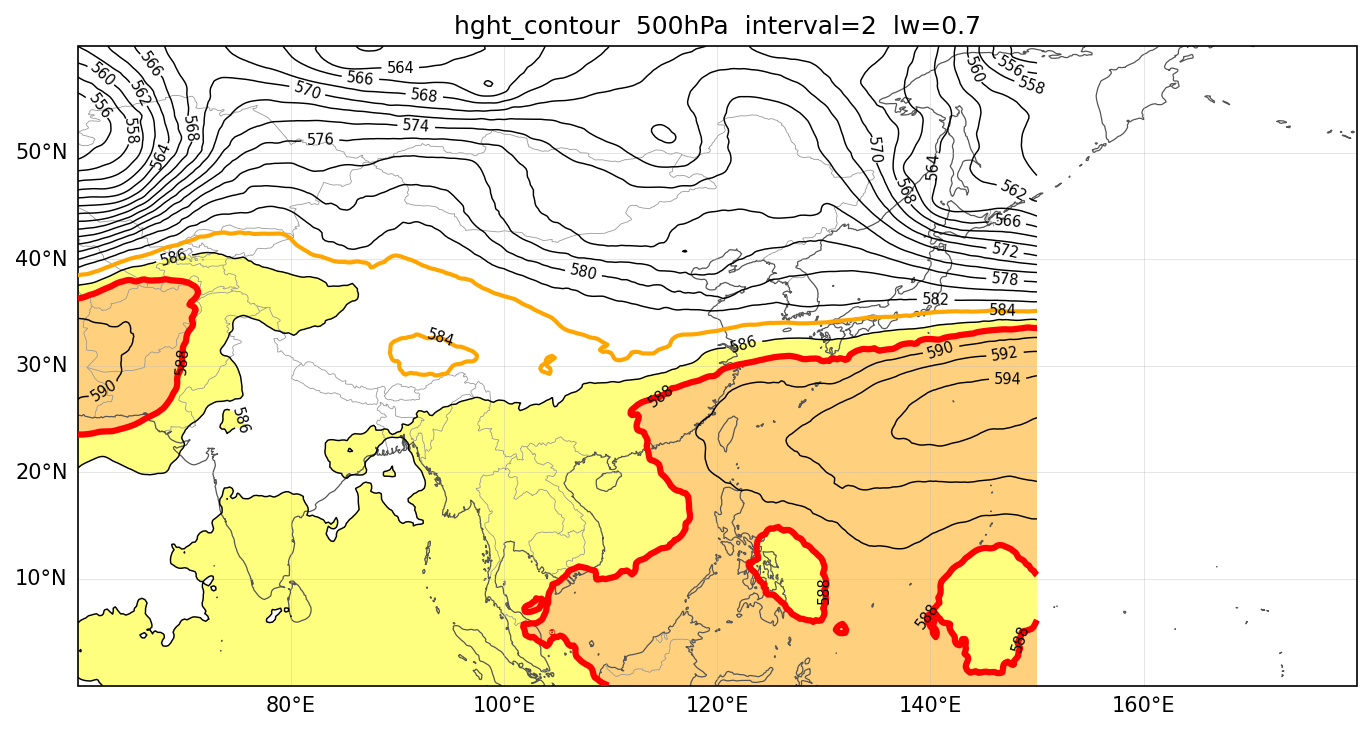

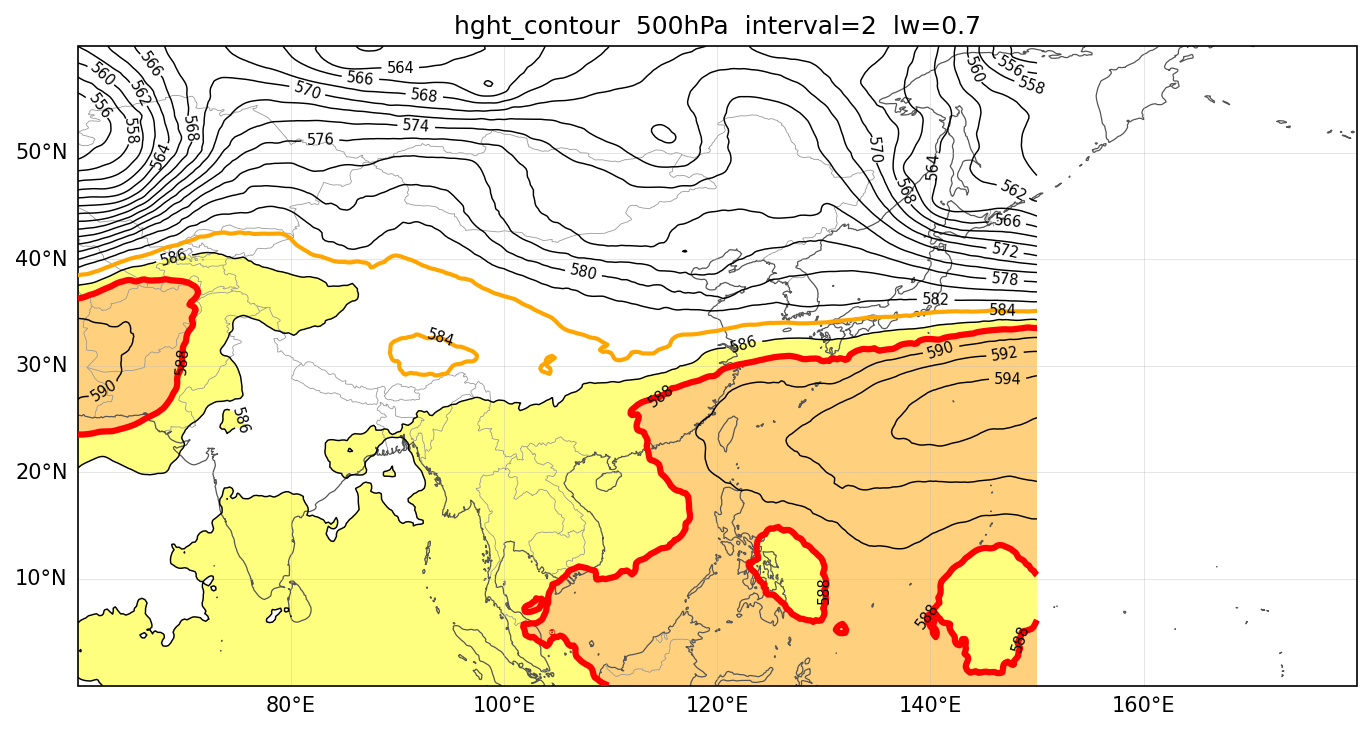

In [7]:
# ===== 可调参数 =====
H_LEVEL = LEVEL          # 层次
CONTOUR_INTERVAL = 2     # 非 500 层等高线间隔 (dagpm)
LINE_COLOR = "black"
LINE_WIDTH = 0.7
# 500 hPa 特征线
HL_588_COLOR, HL_588_WIDTH = "red", 3
HL_584_COLOR, HL_584_WIDTH = "orange", 2
FILL_ALPHA = 0.5

hght = load_hght(H_LEVEL)
fig, ax = preview_axis()
lon, lat = lonlat(hght)
values = np.asarray(hght.values, dtype=float) / 10.0
finite = values[np.isfinite(values)]

if H_LEVEL == 500:
    if np.nanmax(finite) > 586:
        ax.contourf(lon, lat, values, levels=[586, min(588, np.nanmax(finite))],
                    colors=["yellow"], alpha=FILL_ALPHA, transform=ccrs.PlateCarree())
    if np.nanmax(finite) > 588:
        ax.contourf(lon, lat, values, levels=[588, np.nanmax(finite)],
                    colors=["orange"], alpha=FILL_ALPHA, transform=ccrs.PlateCarree())
    cs = ax.contour(lon, lat, values, levels=np.arange(500, 600, CONTOUR_INTERVAL),
                    colors=LINE_COLOR, linewidths=LINE_WIDTH, transform=ccrs.PlateCarree(), zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%d")
    ax.contour(lon, lat, values, levels=[588], colors=HL_588_COLOR,
               linewidths=HL_588_WIDTH, transform=ccrs.PlateCarree(), zorder=4)
    ax.contour(lon, lat, values, levels=[584], colors=HL_584_COLOR,
               linewidths=HL_584_WIDTH, transform=ccrs.PlateCarree(), zorder=4)
else:
    levels = gsl.contour_levels_from_data(values, CONTOUR_INTERVAL)
    cs = ax.contour(lon, lat, values, levels=levels, colors=LINE_COLOR,
                    linewidths=LINE_WIDTH, transform=ccrs.PlateCarree())
    ax.clabel(cs, inline=True, fontsize=7, fmt="%d")

ax.set_title(f"hght_contour  {H_LEVEL}hPa  interval={CONTOUR_INTERVAL}  lw={LINE_WIDTH}")
plt.show()

## 6. 风矢量 `wind_quiver`

可调：抽稀步长 `SKIP`、平滑 `SIGMA`、箭头 `scale`/`width`、颜色。对应 `draw_wind_quiver`。
（`scale` 越大箭头越短；`width` 控制箭杆粗细。）

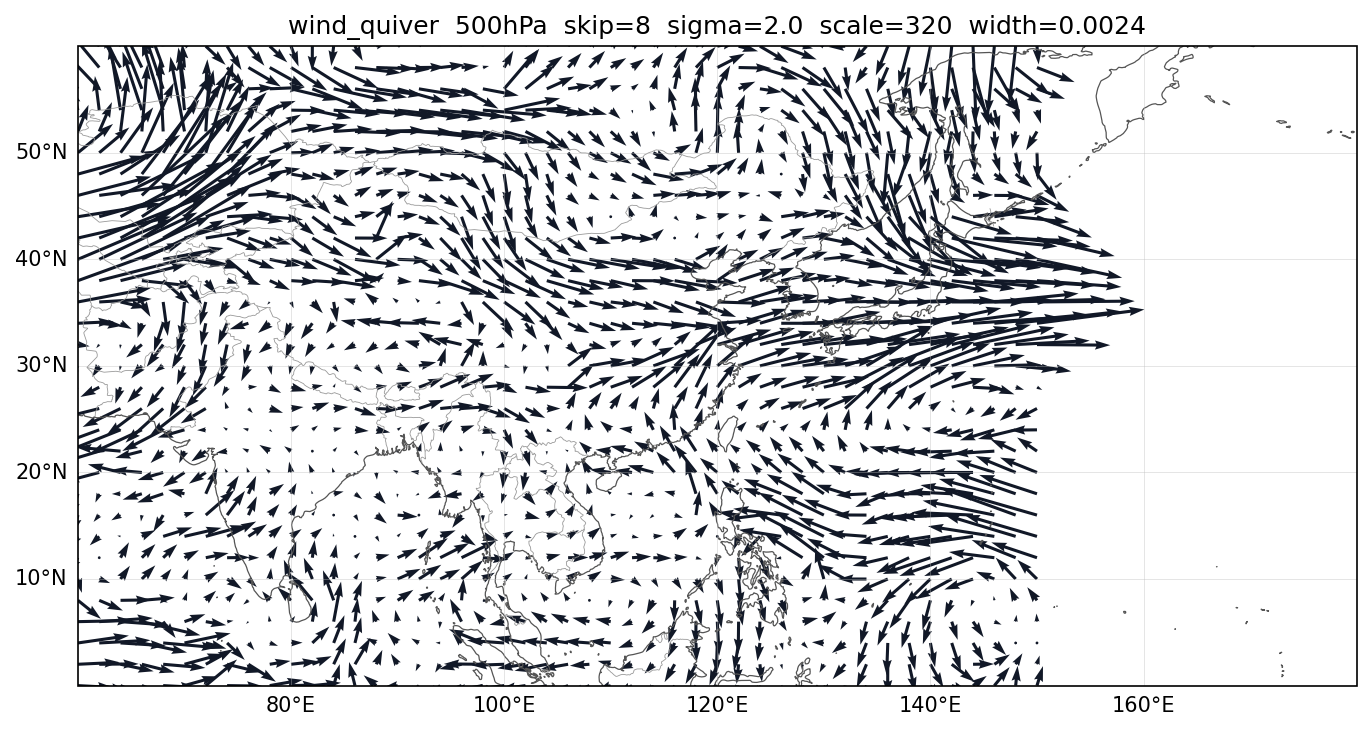

In [8]:
# ===== 可调参数 =====
Q_LEVEL = LEVEL
SKIP = 8
SIGMA = 2.0
SCALE = 320
WIDTH = 0.0024
ARROW_COLOR = "#111827"

u = gsl.smooth_array(load_uwnd(Q_LEVEL), SIGMA)
v = gsl.smooth_array(load_vwnd(Q_LEVEL), SIGMA)
lon, lat = lonlat(u)
fig, ax = preview_axis()
ax.quiver(lon[::SKIP], lat[::SKIP],
          u.values[::SKIP, ::SKIP], v.values[::SKIP, ::SKIP],
          transform=ccrs.PlateCarree(), scale=SCALE, width=WIDTH, color=ARROW_COLOR)
ax.set_title(f"wind_quiver  {Q_LEVEL}hPa  skip={SKIP}  sigma={SIGMA}  scale={SCALE}  width={WIDTH}")
plt.show()

## 7. 风羽 `wind_barb`

可调：抽稀步长、平滑、羽长 `length`、线宽、颜色、风羽增量 `barb_increments`。对应 `draw_wind_barb`。

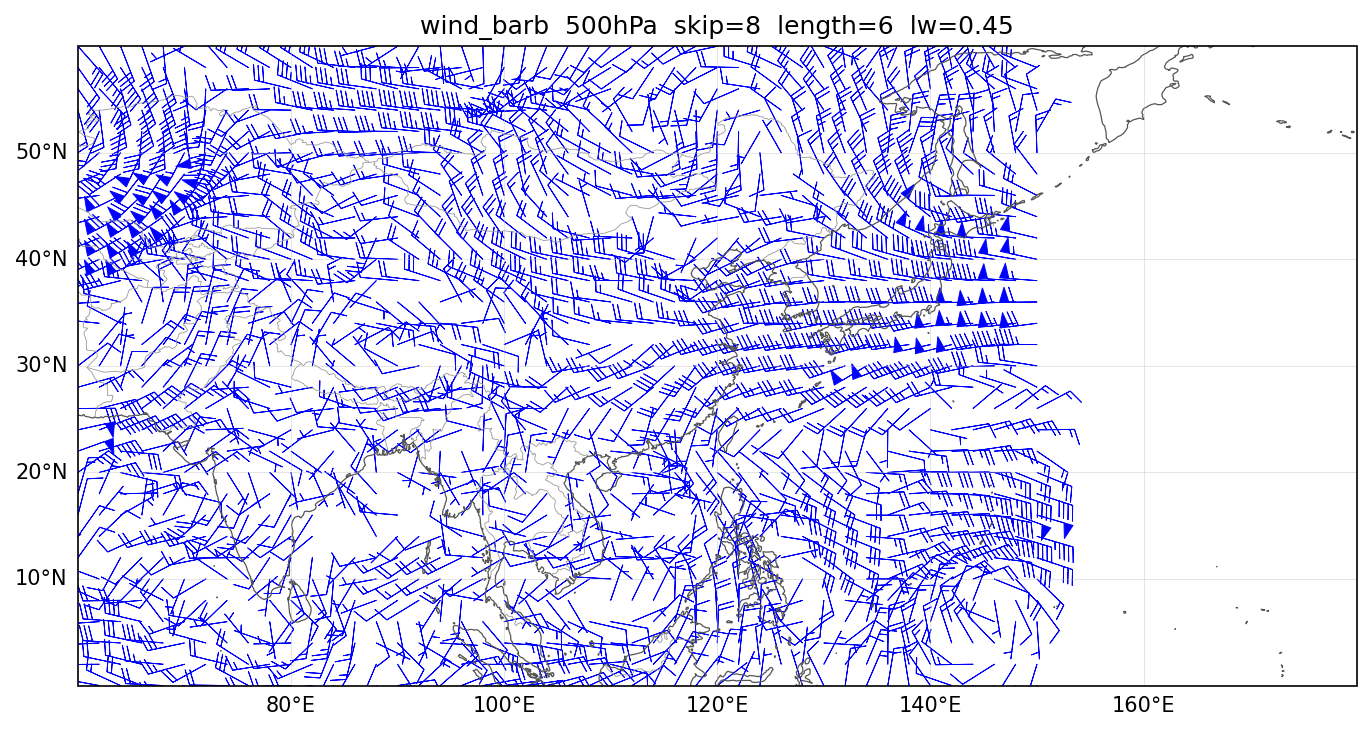

In [9]:
# ===== 可调参数 =====
B_LEVEL = LEVEL
SKIP = 8
SIGMA = 2.0
BARB_LENGTH = 6
BARB_LINEWIDTH = 0.45
BARB_COLOR = "blue"
BARB_INCREMENTS = {"half": 2, "full": 4, "flag": 20}

u = gsl.smooth_array(load_uwnd(B_LEVEL), SIGMA)
v = gsl.smooth_array(load_vwnd(B_LEVEL), SIGMA)
lon, lat = lonlat(u)
fig, ax = preview_axis()
ax.barbs(lon[::SKIP], lat[::SKIP],
         u.values[::SKIP, ::SKIP], v.values[::SKIP, ::SKIP],
         transform=ccrs.PlateCarree(), length=BARB_LENGTH, linewidth=BARB_LINEWIDTH,
         barbcolor=BARB_COLOR, barb_increments=BARB_INCREMENTS, sizes={"emptybarb": 0})
ax.set_title(f"wind_barb  {B_LEVEL}hPa  skip={SKIP}  length={BARB_LENGTH}  lw={BARB_LINEWIDTH}")
plt.show()

## 8. 风速填色 `wind_speed_fill`

可调：平滑 `SIGMA`。色标/分级随层次自动切换（≤500hPa 用高空色标 `CLRMAP_WIND_HIGH`，否则用 `CLRMAP_WIND`），
由 `wind_speed_style(level)` 决定。对应 `draw_wind_speed_fill`。这里附带 colorbar 便于核对分级。

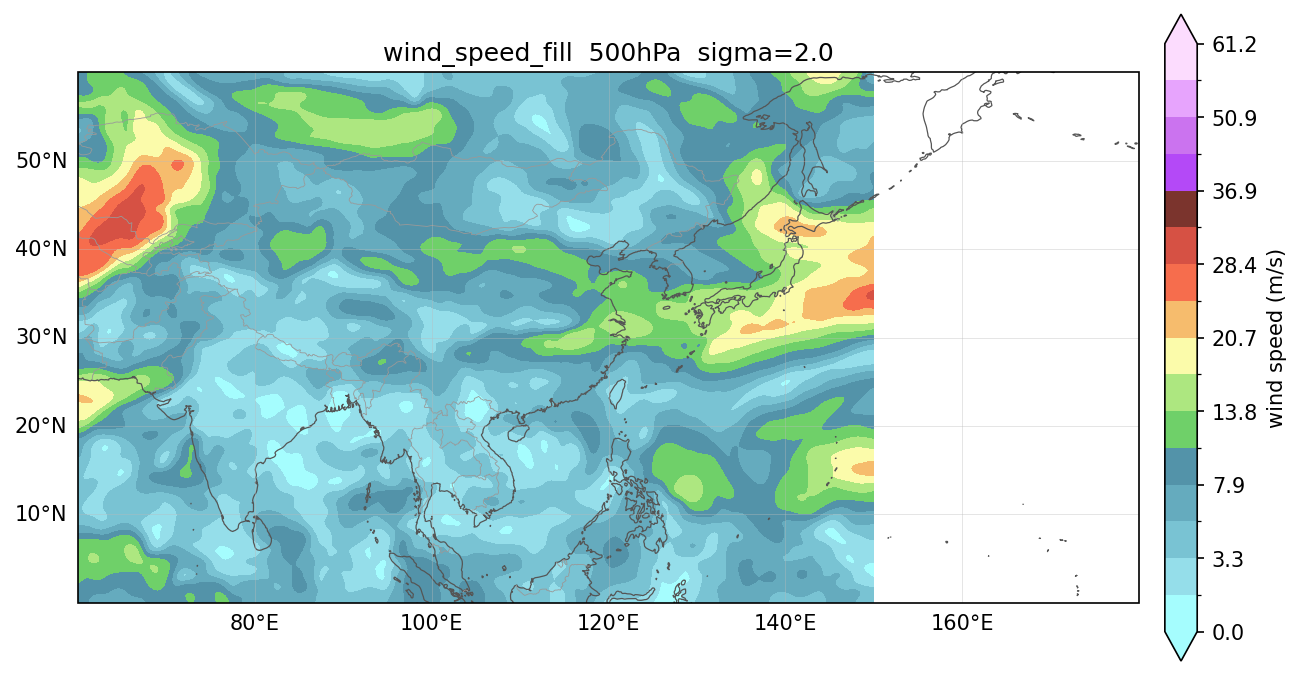

In [10]:
# ===== 可调参数 =====
S_LEVEL = LEVEL
SIGMA = 2.0

speed = gsl.smooth_array(gsl.wind_speed(load_uwnd(S_LEVEL), load_vwnd(S_LEVEL)), SIGMA)
lon, lat = lonlat(speed)
levels, cmap, norm = gsl.wind_speed_style(S_LEVEL)
fig, ax = preview_axis()
cf = ax.contourf(lon, lat, speed.values, levels=levels, cmap=cmap, norm=norm,
                 extend="both", transform=ccrs.PlateCarree())
fig.colorbar(cf, ax=ax, orientation="vertical", shrink=0.7, pad=0.02, label="wind speed (m/s)")
ax.set_title(f"wind_speed_fill  {S_LEVEL}hPa  sigma={SIGMA}")
plt.show()

## 9. 流线 `wind_streamline`

可调：平滑 `SIGMA`、密度 `density`、线宽、箭头大小、颜色。对应 `draw_wind_streamline`。

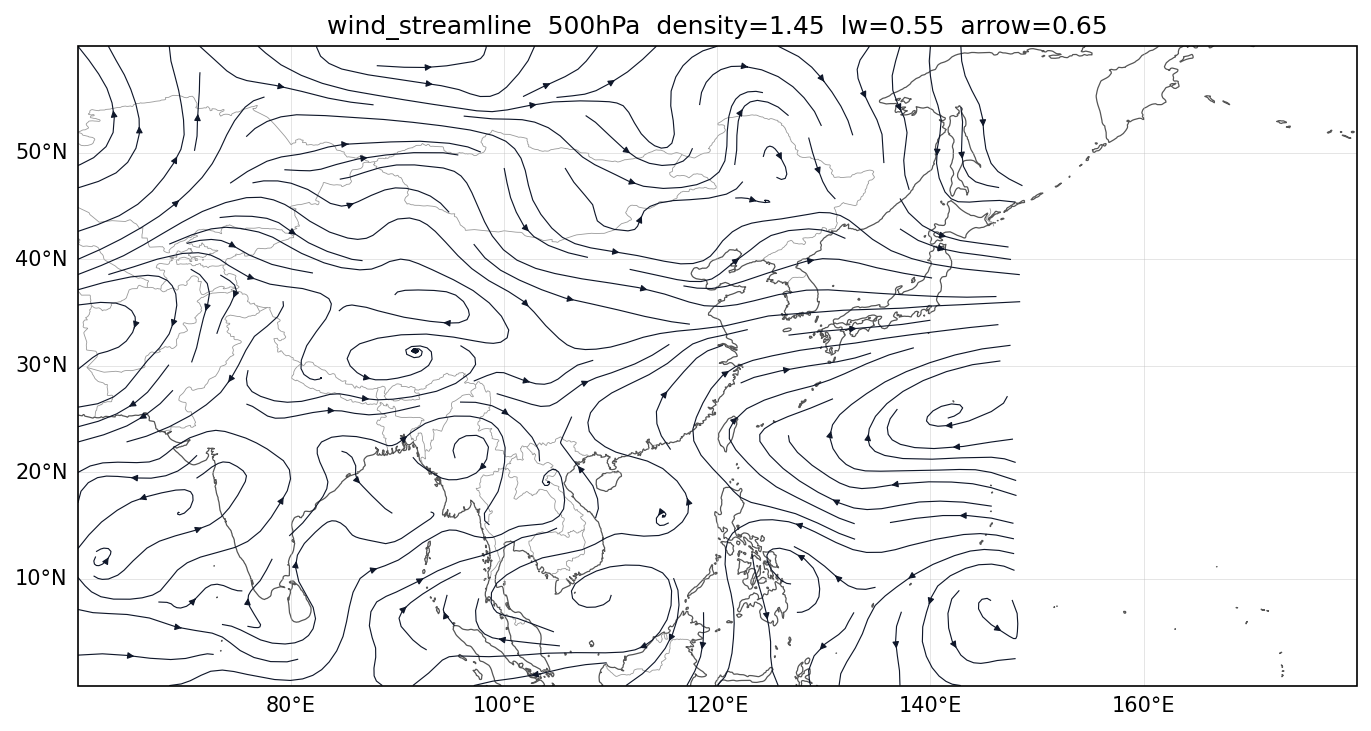

In [11]:
# ===== 可调参数 =====
SL_LEVEL = LEVEL
SIGMA = 2.0
DENSITY = 1.45
LINEWIDTH = 0.55
ARROWSIZE = 0.65
STREAM_COLOR = "#0f172a"

u = gsl.smooth_array(load_uwnd(SL_LEVEL), SIGMA)
v = gsl.smooth_array(load_vwnd(SL_LEVEL), SIGMA)
lon, lat = lonlat(u)
fig, ax = preview_axis()
ax.streamplot(lon, lat, u.values, v.values, density=DENSITY, linewidth=LINEWIDTH,
              arrowsize=ARROWSIZE, color=STREAM_COLOR, transform=ccrs.PlateCarree())
ax.set_title(f"wind_streamline  {SL_LEVEL}hPa  density={DENSITY}  lw={LINEWIDTH}  arrow={ARROWSIZE}")
plt.show()

## 10. 温度等值线 `temp_contour`

可调：线宽（色标/分级 `BOUND_TEMP`、`CLRMAP_TEMP` 来自模块，-40~40℃）。对应 `draw_temp_contour`。

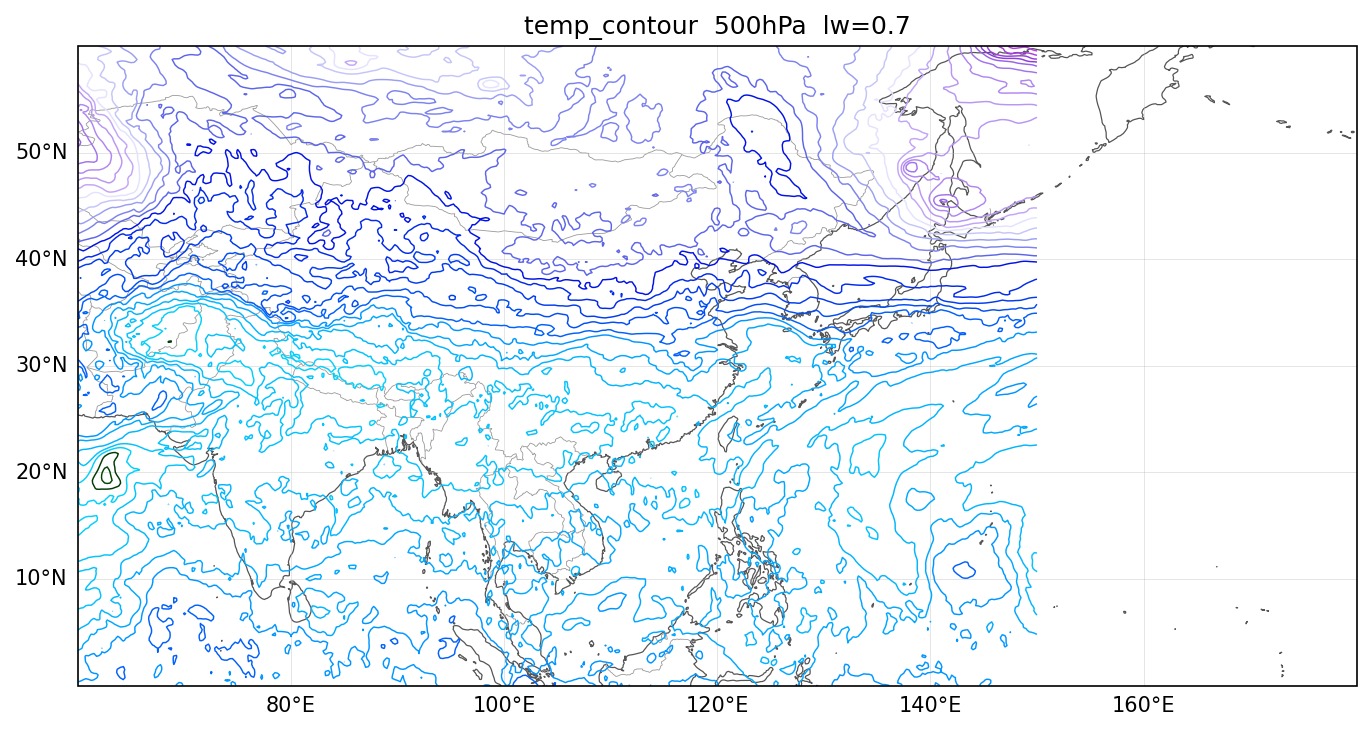

In [12]:
# ===== 可调参数 =====
T_LEVEL = LEVEL
LINE_WIDTH = 0.7

temp_c = gsl.temperature_celsius(load_temp(T_LEVEL))
lon, lat = lonlat(temp_c)
fig, ax = preview_axis()
cs = ax.contour(lon, lat, temp_c.values, levels=gsl.BOUND_TEMP, cmap=gsl.CLRMAP_TEMP,
                norm=gsl.NORMS_TEMP, linewidths=LINE_WIDTH, transform=ccrs.PlateCarree())
ax.set_title(f"temp_contour  {T_LEVEL}hPa  lw={LINE_WIDTH}")
plt.show()

## 11. 涡度填色 `vort_fill`

数值放大 1e5（单位 1e-5 s⁻¹）。色标/分级 `BOUND_VORT`、`CLRMAP_VORT` 来自模块。对应 `draw_vort_fill`。

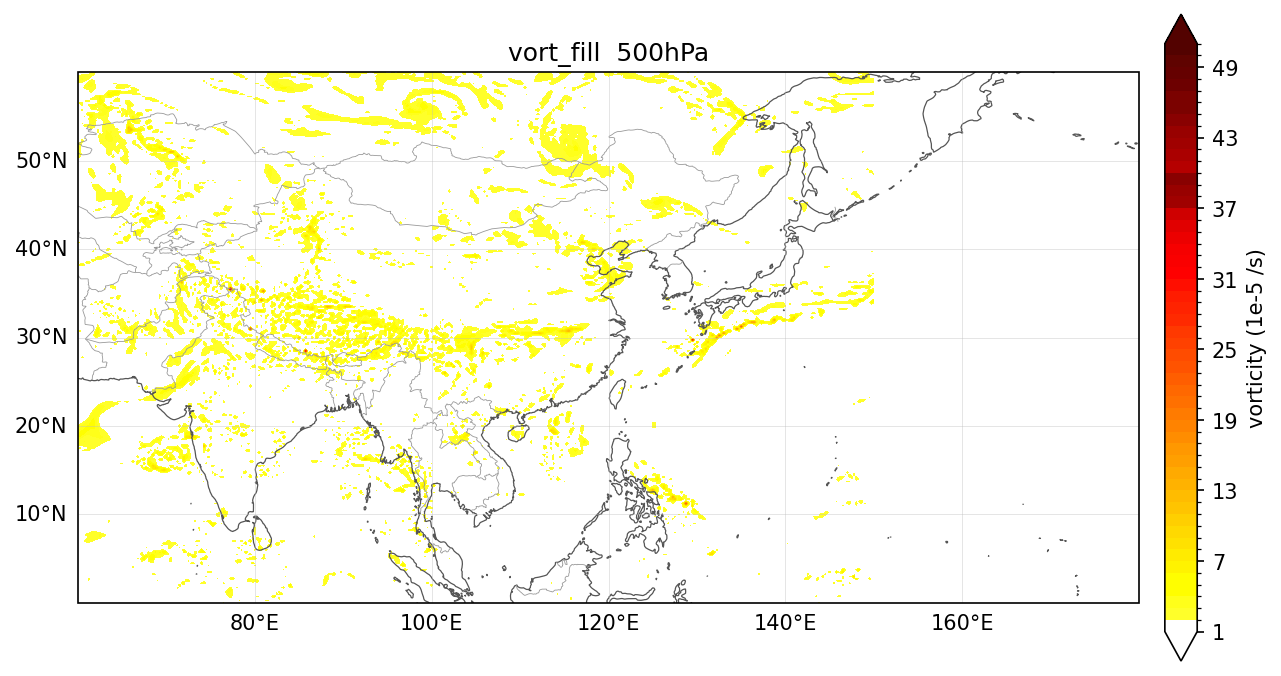

In [20]:
# ===== 可调参数 =====
V_LEVEL = LEVEL
VORT_SCALE = 2*1000000.0   # 放大系数

vort = load_vort(V_LEVEL)
lon, lat = lonlat(vort)
values = np.asarray(vort.values, dtype=float) * VORT_SCALE
fig, ax = preview_axis()
cf = ax.contourf(lon, lat, values, levels=gsl.BOUND_VORT, cmap=gsl.CLRMAP_VORT,
                 norm=gsl.NORMS_VORT, extend="both", transform=ccrs.PlateCarree())
fig.colorbar(cf, ax=ax, orientation="vertical", shrink=0.7, pad=0.02, label="vorticity (1e-5 /s)")
ax.set_title(f"vort_fill  {V_LEVEL}hPa")
plt.show()

## 12. 相对湿度填色 `rhum_fill`

色标/分级 `BOUND_RHUM`、`CLRMAP_RHUM` 来自模块（0~100%）。对应 `draw_rhum_fill`。

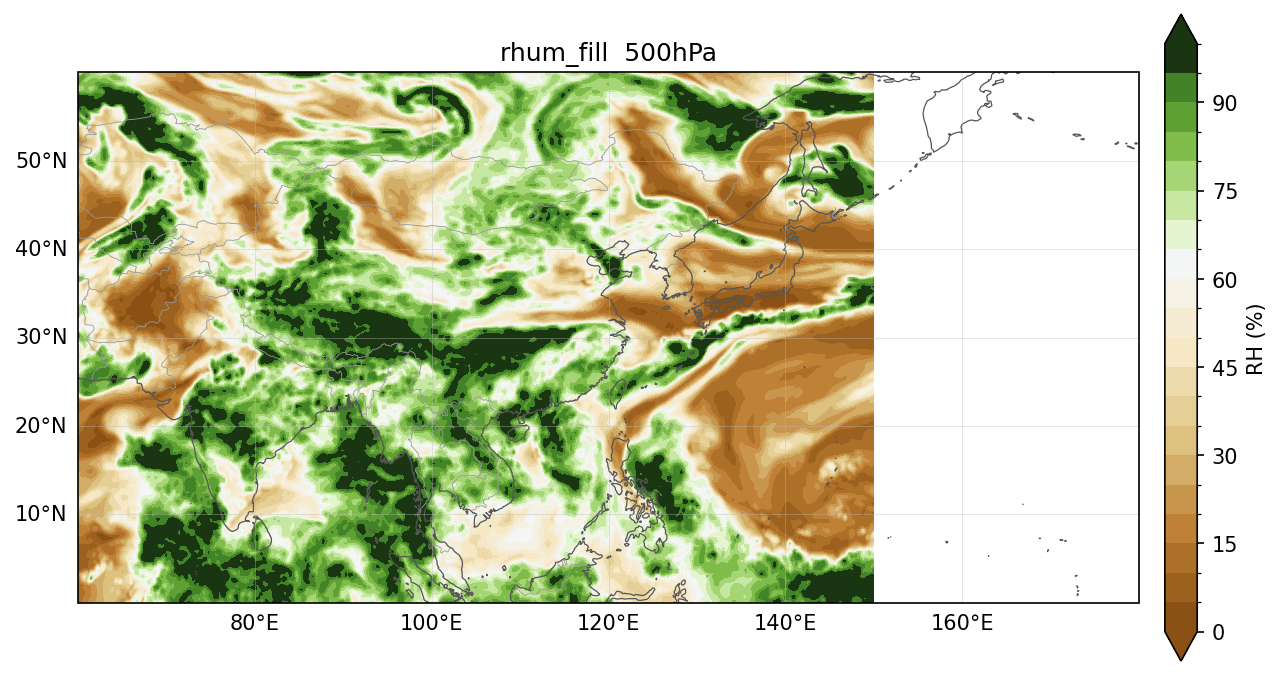

In [21]:
# ===== 可调参数 =====
R_LEVEL = LEVEL

rhum_pct = gsl.relative_humidity_percent(load_rhum(R_LEVEL))
lon, lat = lonlat(rhum_pct)
fig, ax = preview_axis()
cf = ax.contourf(lon, lat, rhum_pct.values, levels=gsl.BOUND_RHUM, cmap=gsl.CLRMAP_RHUM,
                 norm=gsl.NORMS_RHUM, extend="both", transform=ccrs.PlateCarree())
fig.colorbar(cf, ax=ax, orientation="vertical", shrink=0.7, pad=0.02, label="RH (%)")
ax.set_title(f"rhum_fill  {R_LEVEL}hPa")
plt.show()

## 13. 海平面气压等值线 `mslp_contour`（地面层）

可调：等值线间隔、线宽、颜色。对应 `draw_mslp_contour`。

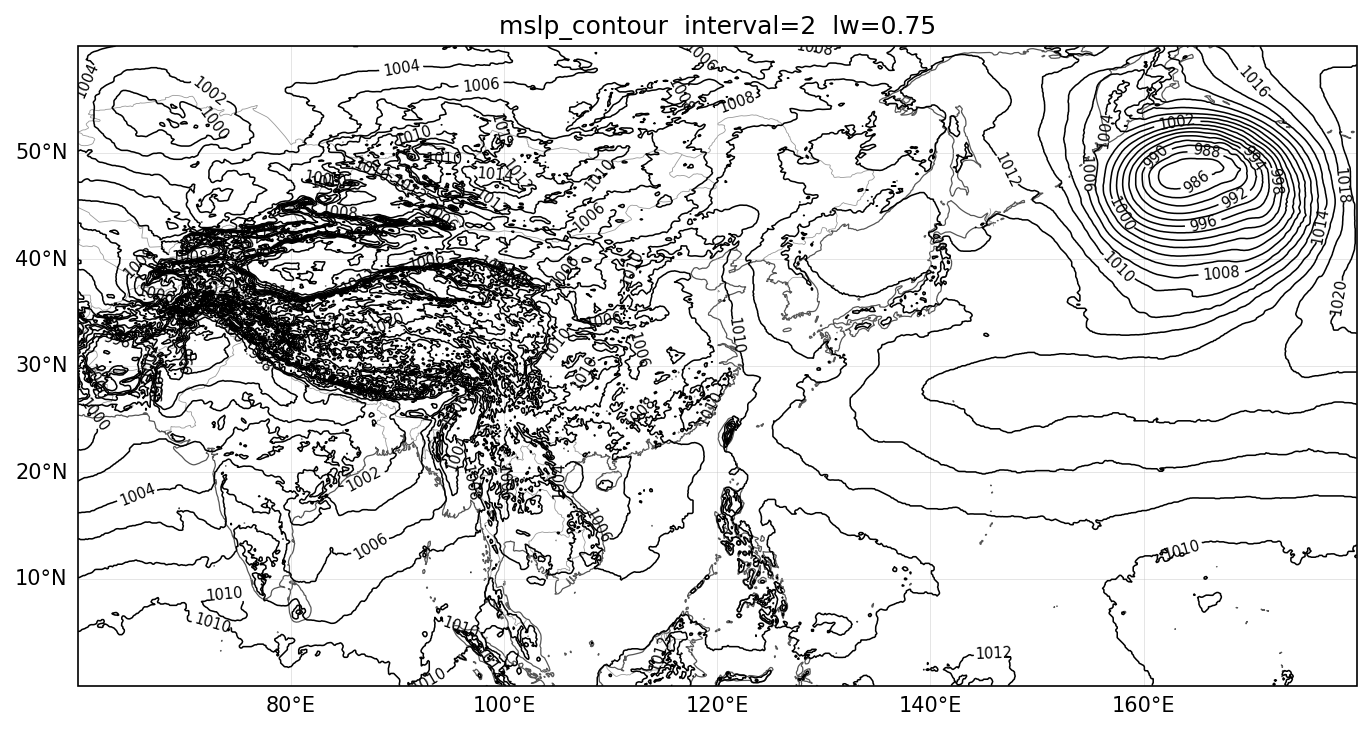

In [22]:
# ===== 可调参数 =====
MSLP_INTERVAL = 2     # 等值线间隔 (hPa)
LINE_COLOR = "black"
LINE_WIDTH = 0.75

mslp = gsl.mslp_hpa(load_mslp())
lon, lat = lonlat(mslp)
values = np.asarray(mslp.values, dtype=float)
levels = gsl.contour_levels_from_data(values, MSLP_INTERVAL)
fig, ax = preview_axis()
cs = ax.contour(lon, lat, values, levels=levels, colors=LINE_COLOR,
                linewidths=LINE_WIDTH, transform=ccrs.PlateCarree())
ax.clabel(cs, inline=True, fontsize=7, fmt="%d")
ax.set_title(f"mslp_contour  interval={MSLP_INTERVAL}  lw={LINE_WIDTH}")
plt.show()

## 14. 地面 10m 风（quiver / barb / speed / streamline）

地面风图层复用上面 `wind_*` 同一套绘图逻辑与参数。需要本地/远程 `u10.nc`、`v10.nc`
（在「全局配置」里设置 `U10_PATH` / `V10_PATH`）。下面用一个单元格切换 `KIND` 预览四种地面风型。

In [ ]:
# ===== 可调参数 =====
KIND = "quiver"   # quiver | barb | speed | streamline
SKIP = 8
SIGMA = 2.0
# quiver
SCALE, WIDTH, ARROW_COLOR = 320, 0.0024, "#111827"
# barb
BARB_LENGTH, BARB_LINEWIDTH, BARB_COLOR = 6, 0.45, "blue"
BARB_INCREMENTS = {"half": 2, "full": 4, "flag": 20}
# streamline
DENSITY, LINEWIDTH, ARROWSIZE, STREAM_COLOR = 1.45, 0.55, 0.65, "#0f172a"

u10 = load_u10()
v10 = load_v10()
fig, ax = preview_axis()

if KIND == "speed":
    speed = gsl.smooth_array(gsl.wind_speed(u10, v10), SIGMA)
    lon, lat = lonlat(speed)
    levels, cmap, norm = gsl.wind_speed_style(None)
    cf = ax.contourf(lon, lat, speed.values, levels=levels, cmap=cmap, norm=norm,
                     extend="both", transform=ccrs.PlateCarree())
    fig.colorbar(cf, ax=ax, shrink=0.7, pad=0.02, label="wind speed (m/s)")
else:
    us = gsl.smooth_array(u10, SIGMA)
    vs = gsl.smooth_array(v10, SIGMA)
    lon, lat = lonlat(us)
    if KIND == "quiver":
        ax.quiver(lon[::SKIP], lat[::SKIP], us.values[::SKIP, ::SKIP], vs.values[::SKIP, ::SKIP],
                  transform=ccrs.PlateCarree(), scale=SCALE, width=WIDTH, color=ARROW_COLOR)
    elif KIND == "barb":
        ax.barbs(lon[::SKIP], lat[::SKIP], us.values[::SKIP, ::SKIP], vs.values[::SKIP, ::SKIP],
                 transform=ccrs.PlateCarree(), length=BARB_LENGTH, linewidth=BARB_LINEWIDTH,
                 barbcolor=BARB_COLOR, barb_increments=BARB_INCREMENTS, sizes={"emptybarb": 0})
    elif KIND == "streamline":
        ax.streamplot(lon, lat, us.values, vs.values, density=DENSITY, linewidth=LINEWIDTH,
                      arrowsize=ARROWSIZE, color=STREAM_COLOR, transform=ccrs.PlateCarree())

ax.set_title(f"surface_{KIND}  skip={SKIP}  sigma={SIGMA}")
plt.show()

## 15.（可选）导出真实透明 SVG 校验

调好参数后，可直接调用模块里的 `draw_*` 生成与正式产品**完全一致**的透明 SVG，
并在 notebook 内联渲染该 SVG 核对最终效果（无底图、透明背景）。
> 注意：模块函数里的参数是**写死**的，这里的导出用于核对当前模块默认效果；
> 想改成调过的值，请把参数回填进 `generate_svg_layers.py`。

In [ ]:
from IPython.display import SVG, display

EXPORT_LAYER = "hght_contour"   # 见 gsl.HIGH_LAYER_TYPES / gsl.SURFACE_LAYER_TYPES
EXPORT_LEVEL = LEVEL
OUT_DIR = NOTEBOOK_DIR / "_preview_svg"
OUT_DIR.mkdir(exist_ok=True)
out_path = OUT_DIR / f"{EXPORT_LAYER}_{EXPORT_LEVEL}.svg"

if EXPORT_LAYER == "hght_contour":
    gsl.draw_hght_contour(load_hght(EXPORT_LEVEL), EXPORT_LEVEL, bounds_obj, out_path, DPI)
elif EXPORT_LAYER == "temp_contour":
    gsl.draw_temp_contour(load_temp(EXPORT_LEVEL), bounds_obj, out_path, DPI)
elif EXPORT_LAYER == "vort_fill":
    gsl.draw_vort_fill(load_vort(EXPORT_LEVEL), bounds_obj, out_path, DPI)
elif EXPORT_LAYER == "rhum_fill":
    gsl.draw_rhum_fill(load_rhum(EXPORT_LEVEL), bounds_obj, out_path, DPI)
elif EXPORT_LAYER == "mslp_contour":
    gsl.draw_mslp_contour(gsl.mslp_hpa(load_mslp()), bounds_obj, out_path, DPI)
elif EXPORT_LAYER in ("wind_quiver", "surface_quiver"):
    lu, lv = (load_u10(), load_v10()) if "surface" in EXPORT_LAYER else (load_uwnd(EXPORT_LEVEL), load_vwnd(EXPORT_LEVEL))
    gsl.draw_wind_quiver(lu, lv, bounds_obj, out_path, DPI, 8, 2.0)
elif EXPORT_LAYER in ("wind_barb", "surface_barb"):
    lu, lv = (load_u10(), load_v10()) if "surface" in EXPORT_LAYER else (load_uwnd(EXPORT_LEVEL), load_vwnd(EXPORT_LEVEL))
    gsl.draw_wind_barb(lu, lv, bounds_obj, out_path, DPI, 8, 2.0)
elif EXPORT_LAYER in ("wind_speed_fill", "surface_speed_fill"):
    lu, lv = (load_u10(), load_v10()) if "surface" in EXPORT_LAYER else (load_uwnd(EXPORT_LEVEL), load_vwnd(EXPORT_LEVEL))
    lvl = None if "surface" in EXPORT_LAYER else EXPORT_LEVEL
    gsl.draw_wind_speed_fill(lu, lv, bounds_obj, out_path, DPI, 2.0, lvl)
elif EXPORT_LAYER in ("wind_streamline", "surface_streamline"):
    lu, lv = (load_u10(), load_v10()) if "surface" in EXPORT_LAYER else (load_uwnd(EXPORT_LEVEL), load_vwnd(EXPORT_LEVEL))
    gsl.draw_wind_streamline(lu, lv, bounds_obj, out_path, DPI, 2.0)
else:
    raise ValueError(f"未知图层类型: {EXPORT_LAYER}")

print("已导出:", out_path)
display(SVG(filename=str(out_path)))